In [1]:
import os
import sys
from pathlib import Path

if 'IS_ROOT_SET' not in globals():
    project_root = Path.cwd().parent.parent.parent
    os.chdir(project_root)
    
    if str(project_root) not in sys.path:
        sys.path.insert(0, str(project_root))
    
    IS_ROOT_SET = True
    print("Корневая директория инициализирована.")
else:
    print("Инициализация уже была выполнена ранее.")
    

Корневая директория инициализирована.


In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

In [3]:
data_root = Path("data/train_dataset_for_students")

Подсчет количества уникальных классов

In [4]:
labels_dir = data_root / "labels"
dirs = ["test", "train", "val"]

In [5]:
import cv2
import numpy as np

all_unique_classes = set()

for dir_name in dirs:
    dir_unique_classes = set()
    
    for file in (labels_dir / dir_name).glob("*.png"):
        image = cv2.imread(str(file), 0)
        
        if image is not None:
            unique_classes = np.unique(image)
            dir_unique_classes.update(unique_classes)
    
    print(f"Количество уникальных классов в {dir_name}: {len(dir_unique_classes)}")
    print(f"Список классов в {dir_name}: {sorted(list(dir_unique_classes))}\n")
    
    all_unique_classes.update(dir_unique_classes)

print(f"Всего уникальных классов во всех папках: {len(all_unique_classes)}")
print(f"Полный список всех классов: {sorted(list(all_unique_classes))}")


Количество уникальных классов в test: 3
Список классов в test: [0, 1, 2]

Количество уникальных классов в train: 3
Список классов в train: [0, 1, 2]

Количество уникальных классов в val: 3
Список классов в val: [0, 1, 2]

Всего уникальных классов во всех папках: 3
Полный список всех классов: [0, 1, 2]


In [6]:
from mmseg.visualization import SegLocalVisualizer
from mmseg.structures import SegDataSample
from mmengine.structures import PixelData
from mmengine.registry import init_default_scope

In [7]:
from mmseg.datasets import TrainDatasetForStudents
from mmseg.utils.class_names import train_dataset_for_students_classes, train_dataset_for_students_palette

In [8]:
init_default_scope('mmseg')

In [9]:
data_root = Path("data/train_dataset_for_students")
data_prefix = dict(img_path=os.path.join("img", "train"), seg_map_path=os.path.join("labels", "train"))

In [10]:
reading_pipeline = [
    dict(type='LoadImageFromFile'), 
    dict(type='LoadAnnotations'),
]

In [11]:
dataset = TrainDatasetForStudents(
    data_root=str(data_root),
    data_prefix=data_prefix,
    img_suffix=".jpg",
    seg_map_suffix=".png",
    pipeline=reading_pipeline,
)

In [12]:
seg_local_visualizer = SegLocalVisualizer(
    vis_backends=[dict(type='LocalVisBackend')],
    save_dir="viz_outputs",
    alpha=0.5,
)

In [13]:
seg_local_visualizer.dataset_meta = dict(
    classes=train_dataset_for_students_classes(),
    palette=train_dataset_for_students_palette(),
)

In [14]:
for i, sample in enumerate(dataset):
    if i % 50 == 0:
        plot_sample = SegDataSample()
        plot_sample.gt_sem_seg = PixelData(data=sample["gt_seg_map"])
        
        if "img_path" in sample:
            img_path = sample["img_path"]
        elif "img_metas" in sample and "filename" in sample["img_metas"]:
            img_path = sample["img_metas"]["filename"]
        elif "img_meta" in sample and "filename" in sample["img_meta"]:
            img_path = sample["img_meta"]["filename"]
        else:
            img_path = f"unknown_{i}.jpg"
            
        file_name = os.path.basename(img_path)
        
        img = sample["img"]
        seg_local_visualizer.add_datasample(
            name=file_name,
            image=img,
            data_sample=plot_sample,
            show=False,
            draw_pred=False
        )

/home/vitaliy/Рабочий стол/Ссылка на Data/programming/2026/yandex_segmentation_project/.venv/lib/python3.10/site-packages/mmengine/structures/pixel_data.py:83: UserWarning: The shape of value will convert from (256, 256) to (1, 256, 256)
  warnings.warn('The shape of value will convert from '


In [15]:
def get_pixels_counts(labels_dir: Path, num_classes: int = 3, seg_map_suffix: str = ".png") -> np.ndarray:
    pixel_counts = np.zeros(num_classes, dtype=np.int64)
    for file in labels_dir.glob(f"*{seg_map_suffix}"):
        mask = cv2.imread(str(file), cv2.IMREAD_GRAYSCALE)
        
        if mask is None:
            continue
        
        counts = np.bincount(mask.ravel(), minlength=num_classes)
        pixel_counts += counts
    return pixel_counts

In [16]:
result = []

for dir in dirs:
    result.append(get_pixels_counts(labels_dir / dir))

In [17]:
result

[array([7056219,  456677,  351424]),
 array([11908826,   653268,   545106]),
 array([7019556,  515420,  329344])]

In [18]:
classes_names = train_dataset_for_students_classes()
classes_palletes = np.array(train_dataset_for_students_palette()) / 255.0

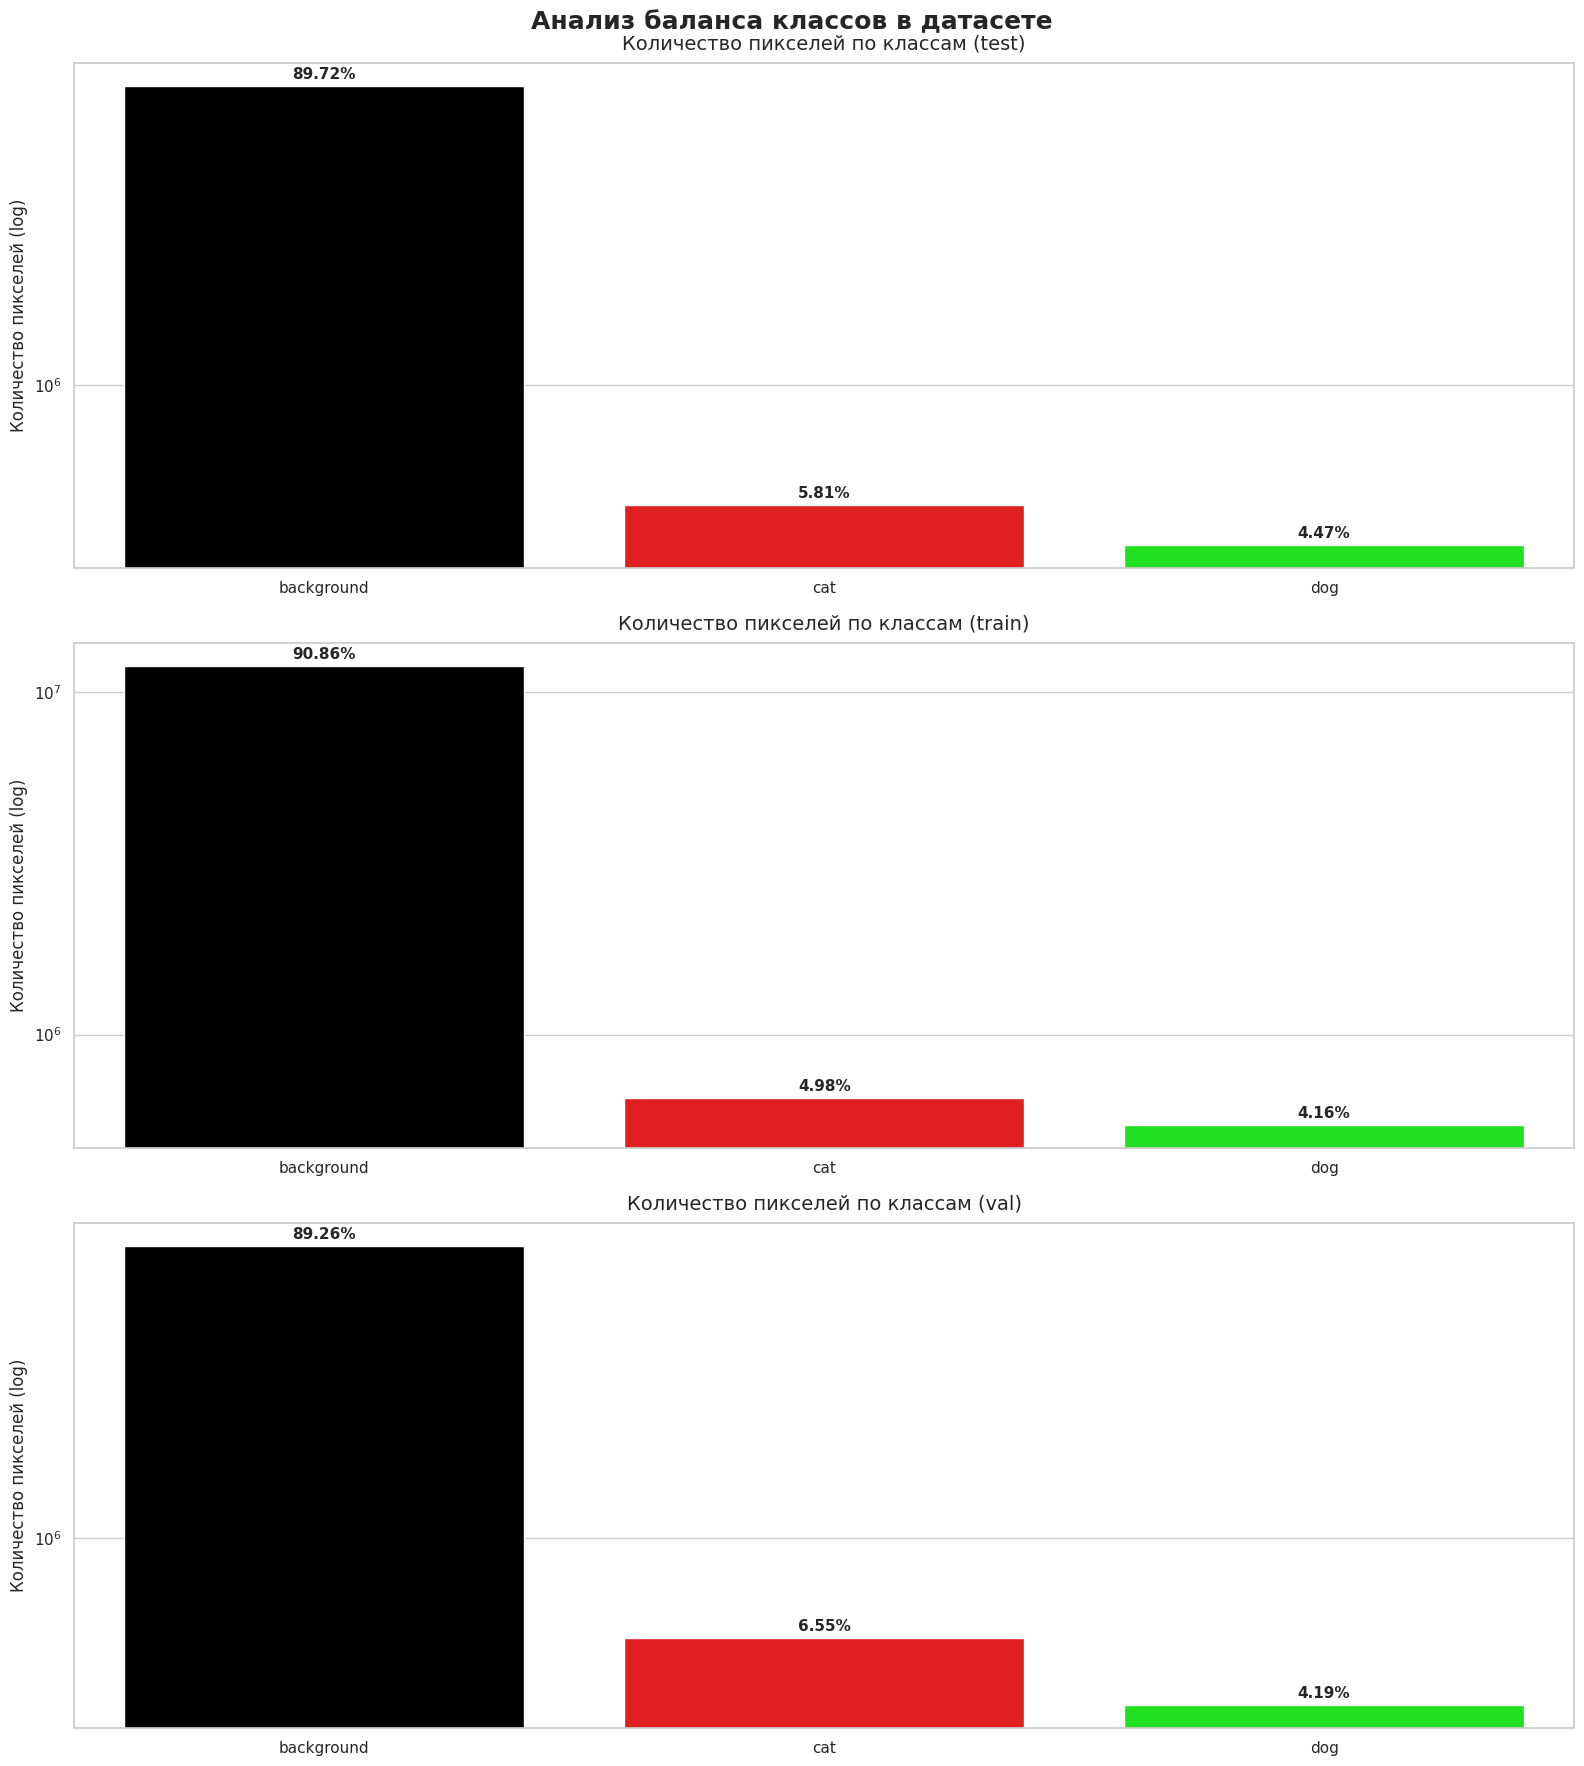

In [19]:
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12})

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(16, 18))
fig.suptitle('Анализ баланса классов в датасете', fontsize=18, fontweight='bold')

barplot1 = sns.barplot(
    x=classes_names,
    y=result[0],
    ax=ax1,
    palette=classes_palletes.tolist(),
    hue=classes_names,
    legend=False,
)
barplot2 = sns.barplot(
    x=classes_names,
    y=result[1],
    ax=ax2,
    palette=classes_palletes.tolist(),
    hue=classes_names,
    legend=False,
)
barplot3 = sns.barplot(
    x=classes_names,
    y=result[2],
    ax=ax3,
    palette=classes_palletes.tolist(),
    hue=classes_names,
    legend=False,
)

axes = [ax1, ax2, ax3]
barplots = [barplot1, barplot2, barplot3]

for i, (ax, barplot, dir) in enumerate(zip(axes, barplots, dirs)):
    ax.set_title(f'Количество пикселей по классам ({dir})', fontsize=14, pad=10)
    ax.set_ylabel('Количество пикселей (log)', fontsize=12)
    ax.set_yscale('log')
    
    current_data = result[i]
    total_pixels = np.sum(current_data)
    
    for patch, val in zip(barplot.patches, current_data):
        percentage = (val / total_pixels) * 100
        
        x = patch.get_x() + patch.get_width() / 2.
        y = patch.get_height()
        
        if y > 0:
            ax.annotate(f"{percentage:.2f}%", 
                        (x, y), 
                        ha='center', va='center', 
                        xytext=(0, 8), 
                        textcoords='offset points', 
                        fontweight='bold',
                        fontsize=11)

plt.tight_layout()
plt.show()

In [20]:
def validate_dataset_alignment(
    image_dir: Path,
    labels_dir: Path,
    image_suffix: str = ".jpg",
    seg_map_suffix: str = ".png"
) -> bool:
    
    stem2path = {file.stem : file for file in image_dir.glob(f"*{image_suffix}")}
    
    images = set(stem2path.keys())
    labels = {label.stem for label in labels_dir.glob(f"*{seg_map_suffix}")}
    
    missing_masks = images - labels
    orphan_masks = labels - images
    
    if orphan_masks:
        print(f"Warning: Найдены лишние маски без картинок ({len(orphan_masks)} шт.)")
        for mask in orphan_masks:
            print(mask)
    
    if missing_masks:
        print("Отсутствуют маски для:")
        for mask in missing_masks:
            print(stem2path[mask])
        return False
    return True
    

In [21]:
for dir in dirs:
    print(f"Проверка: {dir}")
    if validate_dataset_alignment(
        image_dir=data_root / "img" / dir, 
        labels_dir=data_root / "labels" / dir
    ):
        print("Успешно!")
    else:
        print("Не успешно!")

Проверка: test
Успешно!
Проверка: train
Успешно!
Проверка: val
Успешно!


In [22]:
def visualize_dataset_masks(
    image_dir: Path, 
    labels_dir: Path, 
    output_dir: Path,
    img_suffix: str = ".jpg", 
    seg_map_suffix: str = ".png",
    alpha: float = 0.5,
) -> None:
    img_paths = {file.stem: file for file in image_dir.glob(f"*{img_suffix}")}
    mask_paths = {file.stem: file for file in labels_dir.glob(f"*{seg_map_suffix}")}
    
    common_stems = set(img_paths.keys()) & set(mask_paths.keys())
    
    output_dir.mkdir(parents=True, exist_ok=True)
    
    palette = np.array(train_dataset_for_students_palette(), dtype=np.uint8)
    
    for stem in common_stems:
        image_path = img_paths[stem]
        label_path = mask_paths[stem]
        
        image = cv2.imread(str(image_path))
        mask = cv2.imread(str(label_path), cv2.IMREAD_GRAYSCALE)
        
        if image is None or mask is None:
            print(f"Проблема с картинкой или маской: {stem}")
            continue
        
        if image.shape[:2] != mask.shape[:2]:
            print(f"WARNING: Размер картинки и маски не совпадает: {stem}")
            mask = cv2.resize(mask, (image.shape[1], image.shape[0]), interpolation=cv2.INTER_NEAREST)

        color_mask_rgb = palette[mask]
        color_mask_bgr = cv2.cvtColor(color_mask_rgb, cv2.COLOR_RGB2BGR)
        
        overlay = cv2.addWeighted(image, 1.0 - alpha, color_mask_bgr, alpha, 0)
        
        save_path = output_dir / f"{stem}_overlay.jpg"
        cv2.imwrite(filename=str(save_path), img=overlay)            
        
        
        

In [23]:
for dir in dirs:
    visualize_dataset_masks(
        image_dir=data_root / "img" / dir,
        labels_dir=data_root / "labels" / dir,
        output_dir=Path("visualize_dataset") / dir,
    )

In [27]:
import xml.etree.ElementTree as ET

xml_path = "data/train_dataset_for_students/labels/annotations.xml" 
output_dir = "data/train_dataset_for_students/labels/train_fixed" 
os.makedirs(output_dir, exist_ok=True)

class_mapping = {
    "cat": 1,
    "dog": 2
}

tree = ET.parse(xml_path)
root = tree.getroot()

masks_count = 0

for img_tag in root.findall('image'):
    img_name = img_tag.get('name')
    img_width = int(img_tag.get('width'))
    img_height = int(img_tag.get('height'))
    
    full_mask = np.zeros((img_height, img_width), dtype=np.uint8)
    
    for mask_tag in img_tag.findall('mask'):
        label = mask_tag.get('label').lower()
        
        if label in class_mapping:
            class_id = class_mapping[label]
            
            box_left = int(mask_tag.get('left'))
            box_top = int(mask_tag.get('top'))
            box_width = int(mask_tag.get('width'))
            box_height = int(mask_tag.get('height'))
            
            rle_str = mask_tag.get('rle')
            if rle_str:
                counts = list(map(int, rle_str.split(', ')))
                
                flat_mask = np.zeros(box_width * box_height, dtype=np.uint8)
                
                current_val = 0
                idx = 0
                for count in counts:
                    flat_mask[idx:idx+count] = current_val
                    idx += count
                    current_val = 1 - current_val
                
                local_mask = flat_mask.reshape((box_height, box_width))
                
                roi = full_mask[box_top:box_top+box_height, box_left:box_left+box_width]
                roi[local_mask == 1] = class_id
                
                masks_count += 1

    mask_name = os.path.splitext(img_name)[0] + ".png"
    cv2.imwrite(os.path.join(output_dir, mask_name), full_mask)

print(f"Успешно обработано изображений. Найдено и нанесено масок: {masks_count}")


Успешно обработано изображений. Найдено и нанесено масок: 16


In [26]:
visualize_dataset_masks(
    image_dir=data_root / "img" / "train",
    labels_dir=data_root / "labels" / "train_fixed",
    output_dir=Path("visualize_dataset") / "fixed" / "train",
)